# 1교시 시연 — 데이터로 보는 세상 🌍✨

> **이 노트북은 강사 시연용입니다.** 모든 셀이 🔵(수업 중 함께 보는 셀)이에요.
> 코드를 외울 필요 **전혀 없습니다.** "데이터를 가져와 → 화려한 그림으로 보고 → 질문을 던진다"는 *흐름*만 느끼면 됩니다.
> (코드 한 줄 한 줄은 2교시부터 천천히 배웁니다.)

**오늘 구경할 데이터의 세계** — 단 몇 줄로 이 모든 걸 그려봅니다:
1. 💰 **비트코인·금** — 돈의 흐름
2. 🏠 **전국 아파트 실거래가** — 강사의 현장 데이터 (5.7만 건!)
3. 🌍 **세계 행복 보고서 2025** — 어느 나라가 가장 행복할까? 한국은?
4. ⚽ **국제 축구 150년** — 한국 대표팀 1,008경기 (5교시 캡스톤 예고)
5. 🤖 **ChatGPT에게 분석 시키기** — 그리고 *"정말 맞을까?"* ← 오늘의 하이라이트

> 예전엔 데이터 하나 구하는 것도 큰일이었습니다. 지금은 **몇 줄이면** 세상의 데이터가 손안에 들어옵니다.

## 0. 준비 — 도구 + 한글 폰트 + 데이터 한 번에 불러오기 🔵

아래 셀 하나로 (1) 그리기 도구, (2) 한글 폰트(깨짐 방지), (3) 오늘 쓸 데이터 5종을 모두 준비합니다.
**인터넷에서 자동으로 받아오므로** 강의장 어디서든(코랩 포함) 바로 돌아갑니다.

In [1]:
# === 데이터 로드 설정 (로컬/코랩 자동) ===
import os, urllib.request
DATA_BASE = "https://raw.githubusercontent.com/acho98/gunyang-data/main/"
def data_path(fname):
    for _p in ("../data/" + fname, "data/" + fname):
        if os.path.exists(_p):
            return _p
    return DATA_BASE + fname

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# 한글 폰트(배민 도현체): 없으면 자동 다운로드, 실패해도 에러 없이 진행
def set_korean_font():
    _cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]
    if not any(os.path.exists(p) for p in _cands):
        try: urllib.request.urlretrieve(DATA_BASE + "BMDOHYEON.ttf", "BMDOHYEON.ttf")
        except Exception: pass
    for p in _cands:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p)
                plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()
                plt.rcParams["axes.unicode_minus"] = False
                return
            except Exception: pass
    print("(안내) 한글 폰트 미발견 — 영문 라벨은 정상.")
set_korean_font()
plt.rcParams["figure.dpi"] = 110   # 조금 더 선명하게

print("준비 완료! 이제 데이터의 세계로 들어갑니다 ✨")

준비 완료! 이제 데이터의 세계로 들어갑니다 ✨


## 1. 💰 비트코인 — 몇 줄로 가져와 화려하게 그리기 🔵

먼저 비트코인 시세입니다. 표로 보면 숫자만 빼곡하지만, **그림으로 바꾸는 순간** 이야기가 보입니다.

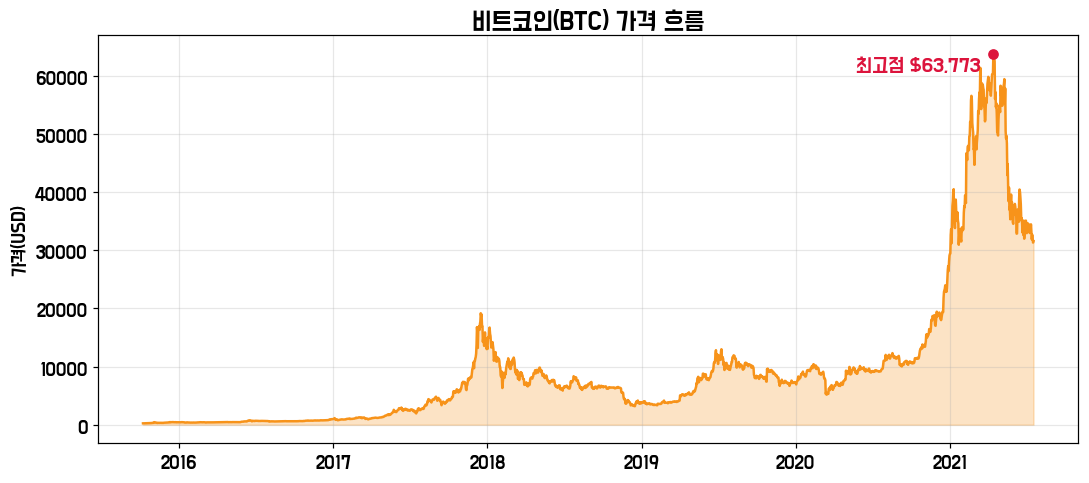

기간: 2015-10 ~ 2021-07
시작 $244  →  최고점 $63,773  (약 262배!)


In [2]:
btc = pd.read_csv(data_path("btc_usd_daily.csv"), skiprows=1)   # 1행은 설명이라 건너뜀
btc["Date"] = pd.to_datetime(btc["Date"])
btc = btc.sort_values("Date")

peak = btc.loc[btc["Close"].idxmax()]   # 최고점 찾기

plt.figure(figsize=(10, 4.5))
plt.fill_between(btc["Date"], btc["Close"], color="#F7931A", alpha=0.25)   # 영역 채우기
plt.plot(btc["Date"], btc["Close"], color="#F7931A", linewidth=1.6)
plt.scatter(peak["Date"], peak["Close"], color="crimson", zorder=5)
plt.annotate(f"최고점 ${peak['Close']:,.0f}", xy=(peak["Date"], peak["Close"]),
             xytext=(-90, -10), textcoords="offset points", color="crimson", fontsize=11)
plt.title("비트코인(BTC) 가격 흐름", fontsize=14)
plt.ylabel("가격(USD)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"기간: {btc['Date'].min():%Y-%m} ~ {btc['Date'].max():%Y-%m}")
print(f"시작 ${btc['Close'].iloc[0]:,.0f}  →  최고점 ${peak['Close']:,.0f}  (약 {peak['Close']/btc['Close'].iloc[0]:.0f}배!)")

**무엇이 보이나요?** 숫자 표였다면 절대 못 느꼈을 **롤러코스터 같은 흐름**이 한눈에 들어옵니다.
시작값의 무려 *260배*까지 치솟았다가 다시 꺾이는 모습 — 이게 4교시에서 배울 **시각화의 힘**입니다.
> 💬 *(강사 일화 자리: 비트코인·코인 투자에 대한 강사의 경험 한마디)*

## 2. 🥇 금(Gold) 시세 — 데이터만 바꾸면 끝 🔵

데이터가 바뀌어도 **방법은 똑같습니다**: 불러오기 → 그림. 이번엔 금 시세예요.

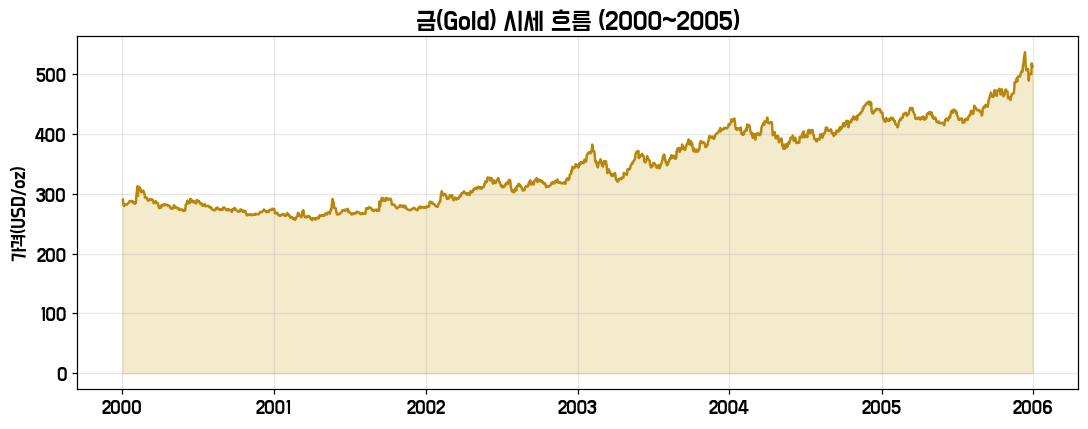

2000년 $290  →  2005년 $513


In [3]:
gold = pd.read_csv(data_path("gold_5y.csv"))
gold["ds"] = pd.to_datetime(gold["ds"])

plt.figure(figsize=(10, 4))
plt.fill_between(gold["ds"], gold["y"], color="#D4AF37", alpha=0.25)
plt.plot(gold["ds"], gold["y"], color="#B8860B", linewidth=1.6)
plt.title(f"금(Gold) 시세 흐름 ({gold['ds'].min():%Y}~{gold['ds'].max():%Y})", fontsize=14)
plt.ylabel("가격(USD/oz)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"{gold['ds'].min():%Y}년 ${gold['y'].iloc[0]:,.0f}  →  {gold['ds'].max():%Y}년 ${gold['y'].iloc[-1]:,.0f}")

비트코인과 똑같은 코드 패턴(`불러오기 → plot`)이죠? **대상이 무엇이든 분석의 문법은 같습니다.**
도구를 한 번 익히면 주식·환율·기온·매출… 무엇에든 그대로 씁니다.

## 3. 🏠 전국 아파트 실거래가 — 진짜 현장 데이터 🔵

이건 **국토교통부가 공개하는 진짜 거래 기록**입니다 (2021년 5월, 전국 **5.7만 건**).
실제 데이터는 처음엔 늘 *지저분*합니다 — 그걸 길들이는 게 분석가의 일이죠.

In [4]:
apt = pd.read_csv(data_path("apt_realprice_202105.csv"))
print("거래 건수:", f"{len(apt):,}", "건")
apt[["시군구", "단지명", "전용면적(㎡)", "거래금액(만원)"]].head(3)

거래 건수: 57,805 건


,시군구,단지명,전용면적(㎡),거래금액(만원)
0,강원도 강릉시 견소동,송정한신,84.945,"19,500"
1,강원도 강릉시 견소동,송정한신,84.945,"19,500"
2,강원도 강릉시 견소동,송정한신,84.945,"19,500"


표의 `거래금액(만원)` 칸을 보세요 — `"19,500"` 처럼 **쉼표가 든 글자**라 이대로는 평균도 못 구합니다.
딱 한 줄로 숫자로 바꾼 뒤(자세한 정제는 **3교시**!), *"어느 동네가 비쌀까?"* 를 그려봅니다.

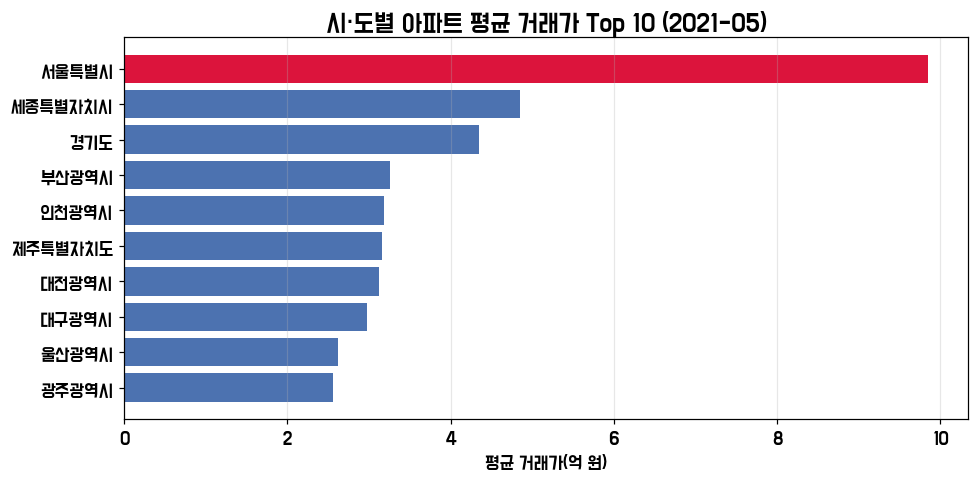

전국 평균: 3.51억  vs  중앙값: 2.45억


In [5]:
# 쉼표 제거 → 숫자로 (정제 맛보기, 자세히는 3교시)
apt["금액"] = apt["거래금액(만원)"].str.replace(",", "").astype(int)
apt["시도"] = apt["시군구"].str.split().str[0]

top = (apt.groupby("시도")["금액"].mean() / 10000).sort_values(ascending=False).head(10)
colors = ["crimson" if v == top.max() else "#4C72B0" for v in top.values]

plt.figure(figsize=(9, 4.5))
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
plt.title("시·도별 아파트 평균 거래가 Top 10 (2021-05)", fontsize=14)
plt.xlabel("평균 거래가(억 원)"); plt.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"전국 평균: {apt['금액'].mean()/10000:.2f}억  vs  중앙값: {apt['금액'].median()/10000:.2f}억")

**서울이 압도적(약 9.8억)** 으로 1위네요. 그런데 마지막 줄을 보세요 —
전국 **평균 3.5억** 인데 **중앙값은 2.5억**. 왜 평균이 더 클까요?
**비싼 서울 거래들이 평균을 끌어올린** 겁니다. → 오늘 배울 **"평균의 함정"** 의 실제 사례예요!

## 4. 🌍 세계 행복 보고서 2025 — 한국은 몇 위? 🔵

데이터는 돈·집만이 아닙니다. **'행복' 같은 추상적인 것도 숫자로** 다룹니다.
2025년 158개국 행복 점수에서, 가장 행복한 나라들과 **우리의 위치**를 함께 봅니다.

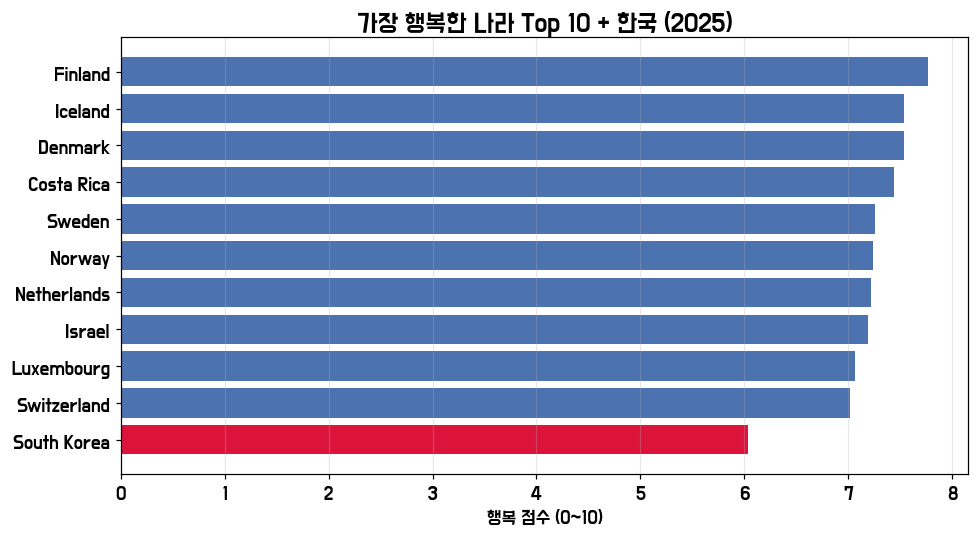

1위: Finland (7.76)
한국: 6.04점, 전체 158개국 중 73위


In [6]:
happy = pd.read_csv(data_path("world_happiness_owid.csv"))
h25 = happy[happy["year"] == 2025].dropna(subset=["cantril_ladder_score"]).copy()
h25 = h25.sort_values("cantril_ladder_score", ascending=False).reset_index(drop=True)

top10 = h25.head(10)
kor = h25[h25["entity"] == "South Korea"]
kor_rank = h25.index[h25["entity"] == "South Korea"][0] + 1

show = pd.concat([top10, kor])
colors = ["#4C72B0"] * len(top10) + ["crimson"]   # 한국만 빨강

plt.figure(figsize=(9, 5))
plt.barh(show["entity"], show["cantril_ladder_score"], color=colors)
plt.gca().invert_yaxis()   # 1위가 맨 위로
plt.title("가장 행복한 나라 Top 10 + 한국 (2025)", fontsize=14)
plt.xlabel("행복 점수 (0~10)"); plt.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"1위: {top10.iloc[0]['entity']} ({top10.iloc[0]['cantril_ladder_score']:.2f})")
print(f"한국: {kor.iloc[0]['cantril_ladder_score']:.2f}점, 전체 {len(h25)}개국 중 {kor_rank}위")

**핀란드가 1위(7.76)**, 북유럽이 상위권을 휩쓸었습니다. 한국은 **6.04점, 73위** — 중상위권이지만 top과는 거리가 있죠.
빨간 막대 하나로 *"우리는 지금 여기"* 가 한눈에. 이렇게 **숫자에 색을 입히면 메시지가 강해집니다.**

## 5. ⚽ 국제 축구 150년 — 한국 대표팀의 전적 🔵

마지막 데이터는 축구입니다. **1872년부터 2026년까지** 전 세계 A매치 4.9만 경기 기록 —
그중 **한국 대표팀 1,008경기**의 승·무·패를 그려봅니다. (5교시 캡스톤에서 직접 분석할 데이터예요!)

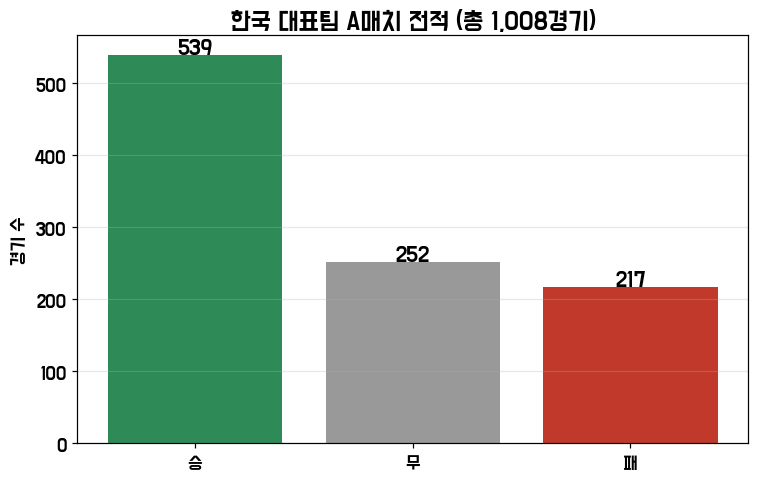

승 539 / 무 252 / 패 217  →  승률 53.5%
(참고) 2026 월드컵 진행 중이라 아직 안 치른 경기는 결측으로 빠져 있어요 — 그것도 데이터의 일부!


In [7]:
wc = pd.read_csv(DATA_BASE + "worldcup_results.csv")   # 캡스톤과 동일 데이터
mask = (wc["home_team"] == "South Korea") | (wc["away_team"] == "South Korea")
kor = wc[mask].dropna(subset=["home_score", "away_score"]).copy()

gf = np.where(kor["home_team"] == "South Korea", kor["home_score"], kor["away_score"])
ga = np.where(kor["home_team"] == "South Korea", kor["away_score"], kor["home_score"])
kor["결과"] = np.where(gf > ga, "승", np.where(gf == ga, "무", "패"))
res = kor["결과"].value_counts().reindex(["승", "무", "패"])

plt.figure(figsize=(7, 4.5))
bars = plt.bar(res.index, res.values, color=["#2E8B57", "#999999", "#C0392B"])
for b, v in zip(bars, res.values):
    plt.text(b.get_x() + b.get_width()/2, v + 5, f"{v}", ha="center", fontsize=12)
plt.title(f"한국 대표팀 A매치 전적 (총 {len(kor):,}경기)", fontsize=14)
plt.ylabel("경기 수"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"승 {res['승']} / 무 {res['무']} / 패 {res['패']}  →  승률 {res['승']/len(kor)*100:.1f}%")
print(f"(참고) 2026 월드컵 진행 중이라 아직 안 치른 경기는 결측으로 빠져 있어요 — 그것도 데이터의 일부!")

**1,008경기 중 539승(승률 53.5%)** — 절반 넘게 이겼네요!
참고로 *아직 안 치른 2026 월드컵 경기*는 점수가 비어 있어 자동으로 빠졌습니다.
이런 **'빈 칸(결측)'을 어떻게 다루느냐**가 3교시·5교시의 핵심 주제예요.

## 6. 🎆 한 장으로 모아 보기 — "데이터 분석이 다루는 세계"

방금 본 네 가지를 **한 화면에** 모아봅니다. 돈, 집, 행복, 스포츠 —
전혀 달라 보이는 주제가 **똑같은 도구 몇 줄**로 모두 그려집니다. 이게 데이터 분석의 힘입니다.

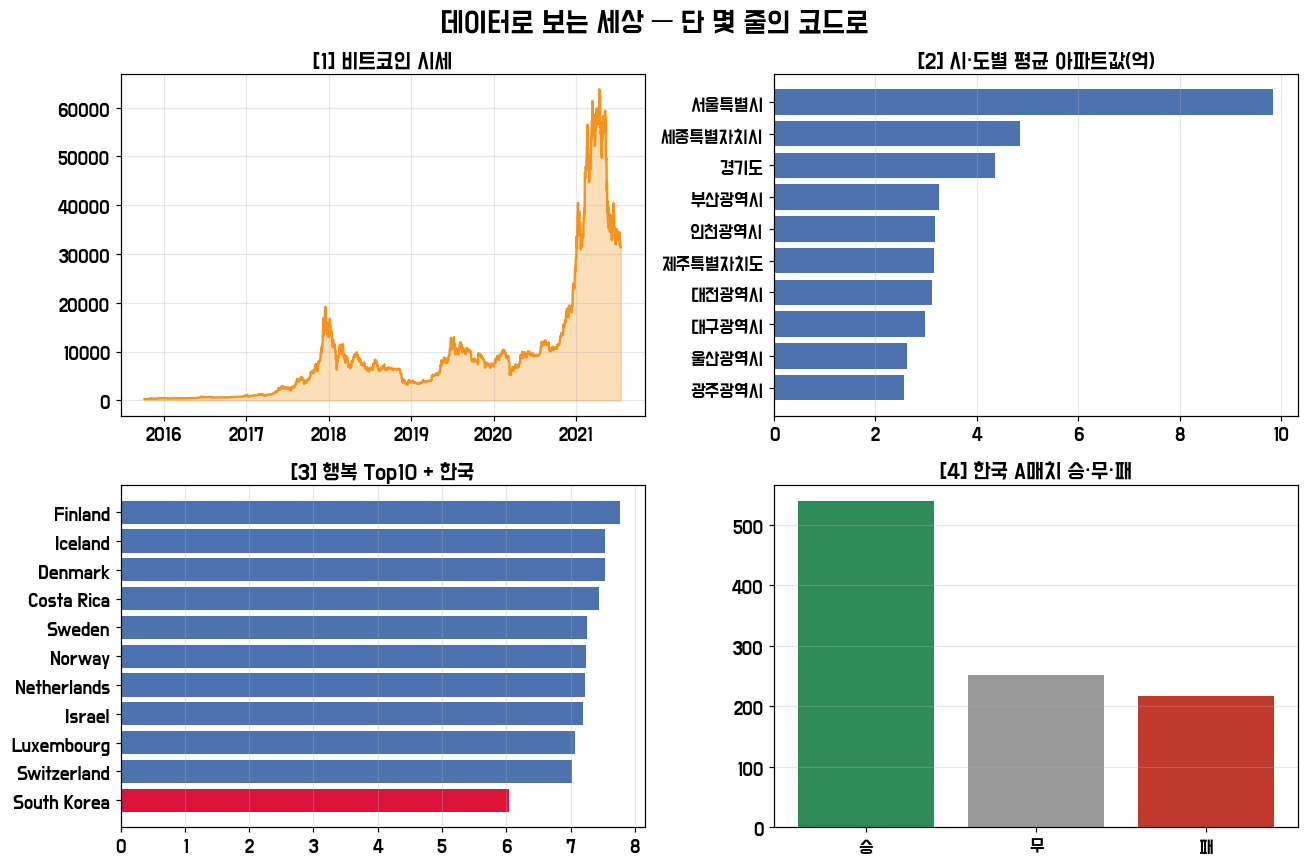

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (1) 비트코인
ax[0,0].fill_between(btc["Date"], btc["Close"], color="#F7931A", alpha=0.3)
ax[0,0].plot(btc["Date"], btc["Close"], color="#F7931A")
ax[0,0].set_title("[1] 비트코인 시세"); ax[0,0].grid(alpha=0.3)

# (2) 부동산 시도별
ax[0,1].barh(top.index[::-1], top.values[::-1], color="#4C72B0")
ax[0,1].set_title("[2] 시·도별 평균 아파트값(억)"); ax[0,1].grid(axis="x", alpha=0.3)

# (3) 세계 행복 Top + 한국
ax[1,0].barh(show["entity"], show["cantril_ladder_score"],
             color=["#4C72B0"]*len(top10)+["crimson"])
ax[1,0].invert_yaxis(); ax[1,0].set_title("[3] 행복 Top10 + 한국"); ax[1,0].grid(axis="x", alpha=0.3)

# (4) 한국 축구 전적
ax[1,1].bar(res.index, res.values, color=["#2E8B57","#999999","#C0392B"])
ax[1,1].set_title("[4] 한국 A매치 승·무·패"); ax[1,1].grid(axis="y", alpha=0.3)

fig.suptitle("데이터로 보는 세상 — 단 몇 줄의 코드로", fontsize=16)
plt.tight_layout(); plt.show()

돈·집·행복·축구. **주제는 달라도 '불러오기 → 그림으로 보기'라는 문법은 하나**입니다.
2교시부터 이 문법을 여러분 손으로 직접 익힙니다. 그런데 그 전에 — 요즘 가장 뜨거운 도구를 하나 써볼까요?

## 7. 🤖 오늘의 하이라이트 — ChatGPT에게 분석을 부탁하기 🔵

이제 코드가 아니라 **사람 말로** 분석을 시켜봅시다.
아래는 ChatGPT에 건넬 작은 카페 판매 표입니다. 강사가 이 표를 붙여넣고 질문할게요.

In [9]:
sample = pd.DataFrame({
    "요일": ["월","화","수","목","금","토","일"],
    "아메리카노": [120,110,115,130,150,210,205],
    "케이크":     [30, 25, 28, 35, 60, 95, 90],
})
sample

,요일,아메리카노,케이크
0,월,120,30
1,화,110,25
2,수,115,28
3,목,130,35
4,금,150,60
5,토,210,95
6,일,205,90


> **강사가 ChatGPT에 입력할 질문(프롬프트) 예시**
>
> ```
> 아래는 카페의 요일별 판매량 표야.
> 1) 주말과 평일 중 언제 더 많이 팔려?
> 2) 아메리카노와 케이크 중 주말 효과가 더 큰 건?
> 3) 사장님께 한 줄로 조언해줘.
>
> 요일,아메리카노,케이크
> 월,120,30
> ...
> ```

### 📸 인터넷·계정이 막혔을 때를 위한 "캡처 대체본"

강의장에서 ChatGPT 접속이 안 될 수 있습니다. 그럴 때는 아래 **예시 답변**으로 대신 보여줍니다.
*(실제 ChatGPT 화면 캡처를 슬라이드에 함께 준비해 두세요.)*

> **🤖 ChatGPT의 답변 (예시)**
>
> 1. **주말이 확실히 더 많이 팔립니다.** 평일 아메리카노는 약 110~150잔인데, 주말(토·일)은 205~210잔으로 늘어요.
> 2. **주말 효과는 '케이크'가 더 큽니다.** 케이크는 평일 평균 약 36개 → 주말 평균 약 92개로 **약 2.6배** 뜁니다.
> 3. **한 줄 조언:** "주말엔 케이크를 평일의 2~3배로 넉넉히 준비하고, 케이크+커피 세트 할인을 거세요."
>
> *(이어서 ChatGPT가 요일별 막대그래프도 깔끔하게 그려줍니다.)*

요즘 AI는 이 정도 계산·요약은 **막힘없이, 꽤 정확하게** 해냅니다. 그런데 — 이걸 그대로 믿고 사장님께 보고해도 될까요?

## 8. 그런데 — AI의 답을 그대로 믿어도 될까? 🔵 (오늘의 핵심)

ChatGPT의 답은 그럴듯하고, **숫자도 대체로 맞습니다.** "AI가 산수를 틀려서" 가 문제가 아니에요.
진짜 함정은 **우리가 건넨 데이터 그 자체**에 있습니다. AI는 우리가 준 데이터의 한계를 **그대로 물려받기** 때문이죠.

- 이 표는 **딱 한 주치**입니다. 이걸로 "항상 주말이 2.6배"라고 단정해도 될까요? (→ *성급한 일반화*)
- "평일 평균 36개"라는 **한 숫자**가 무언가를 **숨기고** 있진 않을까요? 평일이라고 다 같을까요? (→ *평균의 함정*)

> AI는 **계산은 잘하지만, 당신이 준 데이터의 함정(편향·평균의 함정)까지 대신 의심해주진 않습니다.**
> *무엇을 묻고, 무엇을 의심할지* — 그건 여전히 **사람의 몫**입니다.

데이터를 한 겹 더 쪼개서 직접 확인해볼까요?

In [10]:
cake = sample.set_index("요일")["케이크"]
print(f"케이크 평일 평균: {cake[['월','화','수','목','금']].mean():.1f}개")
print(f"케이크 주말 평균: {cake[['토','일']].mean():.1f}개")
print(f"→ 주말은 평일의 약 {cake[['토','일']].mean()/cake[['월','화','수','목','금']].mean():.1f}배 (AI 말이 맞음)\n")

# 그런데 '평일 평균' 한 숫자를 믿지 말고, 평일 속을 들여다보면?
print("[평일 속을 쪼개 보면]")
print(f"  월~목 평균 : {cake[['월','화','수','목']].mean():.1f}개")
print(f"  금요일     : {cake['금']:.0f}개   <- 평일인데 이미 주말급!")

케이크 평일 평균: 35.6개
케이크 주말 평균: 92.5개
→ 주말은 평일의 약 2.6배 (AI 말이 맞음)

[평일 속을 쪼개 보면]
  월~목 평균 : 29.5개
  금요일     : 60개   <- 평일인데 이미 주말급!


> **보셨나요?** AI의 계산(주말은 평일의 약 2.6배)은 **정확합니다.** 문제는 거기가 아니에요.
>
> "평일 평균 36개"라는 한 숫자에 안심하면, **금요일(60개)이 이미 주말만큼 바쁘다**는 사실을 놓칩니다.
> 월~목은 30개 안팎인데 금요일만 60개 — **평균이 이 차이를 뭉개버린** 거죠 (오늘 배울 *평균의 함정*!).
> 게다가 이건 **딱 한 주치** 데이터라, "항상 그렇다"고 단정하면 *성급한 일반화*입니다.
>
> AI는 우리가 준 표를 충실히 계산했을 뿐, *"금요일은 따로 봐야 하지 않아?"*, *"한 주로 단정해도 돼?"* 라고
> **먼저 의심해주지는 않았습니다.** 그 질문을 던지는 것 — **그게 분석가(사람)의 일**입니다.

## 🎯 1교시 마무리

오늘 우리는 **분석의 전체 흐름**을 멀리서 구경했습니다 —
돈·집·행복·축구 데이터를 *가져오고 → 화려한 그림으로 보고 → 질문을 던지고 → 답을 검증*했습니다.

도구(ChatGPT·에이전트)는 점점 똑똑해지지만, 가장 중요한 건 그대로입니다.

> ## "도구는 변해도, 좋은 질문을 던지고 결과를 해석하는 힘은 사람의 몫이다."

그 힘을 기르기 위해, **2교시부터 직접 데이터를 만져봅니다.** 🚀